# **International Arrivals to Vietnam Forecasting**
---
## **1. Problem Introduction**

### **a. Definition**
**Objective:** Predict the total number of international tourist arrivals to Vietnam on a monthly basis from January 2008 to February 2026

**Purpose:**

* plan tourism infrastructure
* forecast revenue for the service sector
* allocate communication and marketing resources
* identify recovery trends after major events (COVID-19)

**Technical representation:** Time Series Forecasting Problem

**Goal:** Model the relationship between the target variable (`international_arrivals_total`) and the explanatory variables (`date_month_start`, `positive_event_flag` and `negative_event_flag` in `exogenous_arrivals.csv`)

### **b. Methodology:** **Linear Regression** for time series forecasting
**First stage:** Linear Regression with **Gradient Descent** (univariate baseline)

**Next stage:** apply **Normal Equation** (multivariate model)

**Purpose:** compare optimization methods, extend the model with more explanatory variables while maintaining computational efficiency

### **c. Dataset**

`endogenous_arrivals.csv`: monthly dates, total arrivals

`exogenous_arrivals.csv`: binary flags for positive, negative events

`combined_arrivals.csv`: merged dataset, utilized in the final Normal Equation model

---
## **2. Code Implementation**

### **a. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **b. Preprocessing Data**

#### **b.1. Load, Read, Combine Data**

In [2]:
#1. READ AND COMBINE DATA
df_endo = pd.read_csv('endogenous_arrivals.csv')
df_endo.head()

,date_month_start,international_arrivals_total
0,2008-01-01,399556
1,2008-02-01,411032
2,2008-03-01,414332
3,2008-04-01,395900
4,2008-05-01,366387


In [3]:
file_exo = 'exogenous_arrivals.csv'
df_exo = pd.read_csv(file_exo)

#Merge data base on mutual 'date_month_start' column, then convert into new file
df_comb = pd.merge(df_endo, df_exo[['date_month_start', 'positive_event_flag', 'negative_event_flag']], on='date_month_start', how = 'left')
df_comb.to_csv('combined_arrivals.csv', index=False)
df_comb.head()

,date_month_start,international_arrivals_total,positive_event_flag,negative_event_flag
0,2008-01-01,399556,1,0
1,2008-02-01,411032,1,0
2,2008-03-01,414332,0,1
3,2008-04-01,395900,1,0
4,2008-05-01,366387,1,0


In [4]:
#Initialize base time index t = 0, 1, 2...
df_comb['t'] = np.arange(len(df_comb))
df_comb['date_month_start'] = pd.to_datetime(df_comb['date_month_start'])

#### **b.2. Visualize Dataset to detect anomalies**

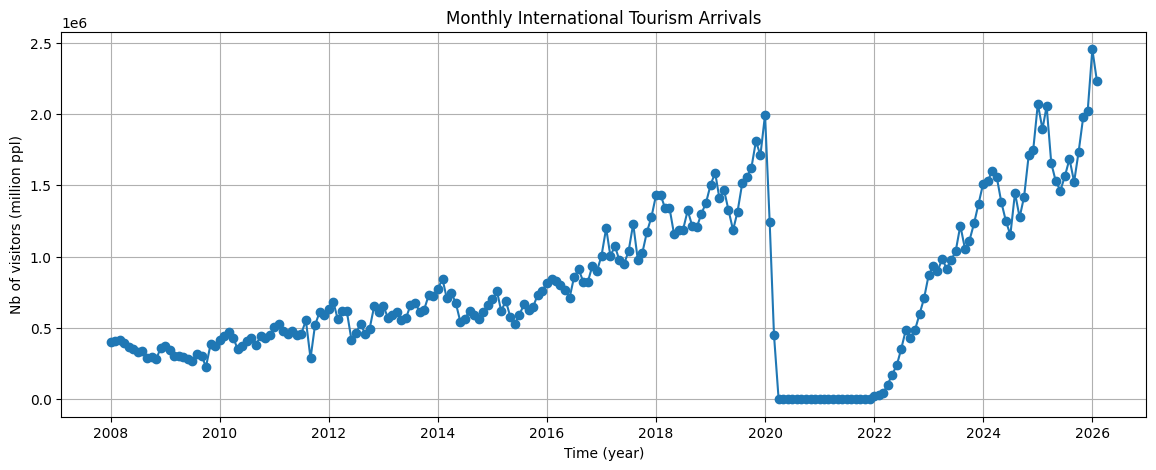

In [5]:
#2. ORIGINAL DATA VISUALIZATION TO DETECT ANOMALIES
plt.figure(figsize = (14, 5))
plt.plot(df_comb['date_month_start'], 
        df_comb['international_arrivals_total'], 
        marker = 'o', linestyle = '-')
plt.title("Monthly International Tourism Arrivals")
plt.xlabel("Time (year)")
plt.ylabel("Nb of visitors (million ppl)")
plt.grid(True)
plt.show()

From the graph: period 2020 - 2021: a sudden fall-off, no longer represent the previous normal trend

#### **b.3. Train - Test split**

We have to split the data in to: 

- 2008 - 2019: train data

- 2020 - 2021: skip because of COVID-19, cannot have any model to predict this period

- 2022 - 2023: the recovery period => validate data

- 2024 - 2026: test data

In [6]:
#3. SPLIT INTO TRAIN - COVID - VALID - TEST DATA
#Create timelines for each dataset
train_start = '2008-01-01'
train_end = '2019-12-31'

covid_start = '2020-01-01'
covid_end = '2021-12-31'

val_start = '2022-01-01'
val_end = '2023-12-31'

test_start = '2024-01-01'
test_end = '2026-02-28'

    #Split data based on time conditions
    #copy(): avoid pandas warnings when creating new columns
#Train data (2008 - 2019)
df_train = df_comb[(df_comb['date_month_start'] >= train_start) & (df_comb['date_month_start'] <= train_end)].copy()
#Covid data (2020 - 2021) - NOT TO TRAIN DATA
df_covid = df_comb[(df_comb['date_month_start'] >= covid_start) & (df_comb['date_month_start'] <= covid_end)].copy()
#Validation data (2022 - 2023)
df_val = df_comb[(df_comb['date_month_start'] >= val_start) & (df_comb['date_month_start'] <= val_end)].copy()
#Test data (2024 - 2026)
df_test = df_comb[(df_comb['date_month_start'] >= test_start) & (df_comb['date_month_start'] <= test_end)].copy()

#Print to check len of each dataset
split_summary_df = pd.DataFrame({
    'dataset': ['Train', 'COVID', 'Validation', 'Test'],
    'start': [df_train['date_month_start'].min(), df_covid['date_month_start'].min(), df_val['date_month_start'].min(), df_test['date_month_start'].min()],
    'end':[df_train['date_month_start'].max(), df_covid['date_month_start'].max(), df_val['date_month_start'].max(), df_test['date_month_start'].max()],
    'nb_of_months': [len(df_train), len(df_covid), len(df_val), len(df_test)]
})
display(split_summary_df)

,dataset,start,end,nb_of_months
0,Train,2008-01-01,2019-12-01,144
1,COVID,2020-01-01,2021-12-01,24
2,Validation,2022-01-01,2023-12-01,24
3,Test,2024-01-01,2026-02-01,26


#### **b.4. Normalize Data**

In [7]:
#4. CALCULATE NORMALIZE PARAMETERS 
t_mean, t_std = df_train['t'].mean(), df_train['t'].std()
y_mean, y_std = df_train['international_arrivals_total'].mean(), df_train['international_arrivals_total'].std()
pos_mean, pos_std = df_train['positive_event_flag'].mean(), df_train['positive_event_flag'].std()
neg_mean, neg_std = df_train['negative_event_flag'].mean(), df_train['negative_event_flag'].std()

#in case std = 0 get error / 0
if pos_std == 0: pos_std = 1
if neg_std == 0: neg_std = 1

#==================================================
#5. NORMALIZE FUNCTION FOR 3 DATASETS (EXCEPT COVID)
def scale_datasets(df):
    #eg for train dataset
    df['t_scaled'] = (df['t'] - t_mean) / t_std
    df['y_scaled'] = (df['international_arrivals_total'] - y_mean) / y_std
    df['pos_scaled'] = (df['positive_event_flag'] - pos_mean) / pos_std
    df['neg_scaled'] = (df['negative_event_flag'] - neg_mean) / neg_std
    return df

#apply for all
df_train = scale_datasets(df_train)
df_val = scale_datasets(df_val)
df_test = scale_datasets(df_test)

#### **b.5. Create matrix X, Y in Train - Validation - Test Set**

In [8]:
#6. CREATE MATRIX X, Y IN NUMPY
#Gradient Descent (only t_scaled)
X_train_endo = np.c_[np.ones(len(df_train)), df_train['t_scaled'].values]
Y_train = df_train['y_scaled'].values.reshape(-1, 1)

X_val_endo = np.c_[np.ones(len(df_val)), df_val['t_scaled'].values]
Y_val = df_val['y_scaled'].values.reshape(-1, 1)

X_test_endo = np.c_[np.ones(len(df_test)), df_test['t_scaled'].values]
Y_test = df_test['y_scaled'].values.reshape(-1, 1)

#Normal Equation (t_scaled, pos_scaled, neg_scaled)
X_train_comb = np.c_[np.ones(len(df_train)),
                     df_train['t_scaled'].values,
                     df_train['pos_scaled'].values,
                     df_train['neg_scaled'].values]

X_val_comb = np.c_[np.ones(len(df_val)),
                     df_val['t_scaled'].values,
                     df_val['pos_scaled'].values,
                     df_val['neg_scaled'].values]

X_test_comb = np.c_[np.ones(len(df_test)),
                     df_test['t_scaled'].values,
                     df_test['pos_scaled'].values,
                     df_test['neg_scaled'].values]

### **b.6. Check matrix shape**

In [9]:
#7. PRINT TO CHECK
print("\n--- Train matrix size for Gradient Descent ---")
print("X_train_endo shape:", X_train_endo.shape)
print("Y_train shape:", Y_train.shape)

print("\n--- Train matrix size for Normal Equation ---")
print("X_train_comb shape:", X_train_comb.shape)
print("Y_train shape:", Y_train.shape)

print("\n--- Validation matrix size ---")
print("X_val_endo shape:", X_val_endo.shape)
print("X_val_comb shape:", X_val_comb.shape)
print("Y_val shape:", Y_val.shape)

print("\n--- Test matrix size ---")
print("X_test_endo shape:", X_test_endo.shape)
print("X_test_comb shape:", X_test_comb.shape)
print("Y_test shape:", Y_test.shape)


--- Train matrix size for Gradient Descent ---
X_train_endo shape: (144, 2)
Y_train shape: (144, 1)

--- Train matrix size for Normal Equation ---
X_train_comb shape: (144, 4)
Y_train shape: (144, 1)

--- Validation matrix size ---
X_val_endo shape: (24, 2)
X_val_comb shape: (24, 4)
Y_val shape: (24, 1)

--- Test matrix size ---
X_test_endo shape: (26, 2)
X_test_comb shape: (26, 4)
Y_test shape: (26, 1)


### **c. Gradient Descent, Cost Function Plot, Evaluation**

In [10]:
def init(dim):
    return np.random.rand(dim, 1)
def predict_Y(theta, X):
    return np.dot(X, theta)

def get_cost(Y, Y_hat):
    m = len(Y)
    cost = (1/(2*m)) * np.sum((Y_hat - Y) ** 2)
    return cost

def run_gradient_descent(X, Y, theta, alpha, iterations):
    m = len(Y)
    cost_history = []

    for i in range (iterations):
        Y_hat = predict_Y(theta, X)
        gradient = (1/m) * np.dot(X.T, (Y_hat - Y))
        theta = theta - alpha * gradient
        new_Y_hat = predict_Y(theta, X)
        cost = get_cost(Y, new_Y_hat)
        cost_history.append(cost)
    return theta, cost_history


**Evaluate Model**

In [11]:
def evaluate_model(Y, Y_hat):
    mae = np.mean(np.abs(Y - Y_hat))
    mse = np.mean((Y - Y_hat) ** 2)
    rmse = np.sqrt(mse)

    ss_tot = np.sum((Y - np.mean(Y)) ** 2)
    ss_res = np.sum((Y - Y_hat) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    print(f"MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R^2: {r2:.4f}")

**Run Gradient Descent**

In [12]:
alpha = 0.01
iterations = 1000
theta_endo = init(X_train_endo.shape[1])

print("\n---Gradient Descent---")
theta_endo, cost_history = run_gradient_descent(X_train_endo, Y_train, theta_endo, alpha, iterations)
print("X_train shape:", X_train_endo.shape)
print("Y_train shape:", Y_train.shape)
print("Theta shape:", theta_endo.shape)
print("Optimized Theta:", theta_endo.flatten())


---Gradient Descent---
X_train shape: (144, 2)
Y_train shape: (144, 1)
Theta shape: (2, 1)
Optimized Theta: [3.66805238e-05 9.12512270e-01]


**Cost Function**

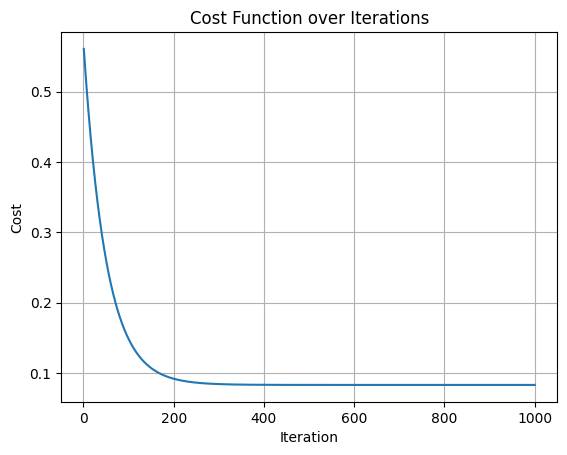

In [13]:
plt.plot(range(1, iterations + 1), cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function over Iterations")
plt.grid(True)
plt.show()

The cost decreases quickly at first and then stablizes, which indicates that Gradient Descent converges well

**Gradient Descent Evaluation**

In [14]:
Y_train_pred_endo = predict_Y(theta_endo, X_train_endo)
Y_val_pred_endo = predict_Y(theta_endo, X_val_endo)
Y_test_pred_endo = predict_Y(theta_endo, X_test_endo)

print("\nEvaluate Gradient Descent on TRAIN set:")
evaluate_model(Y_train, Y_train_pred_endo)

print("\nEvaluate Gradient Descent on VALIDATION set:")
evaluate_model(Y_val, Y_val_pred_endo)

print("\nEvaluate Gradient Descent on TEST set:")
evaluate_model(Y_test, Y_test_pred_endo)


Evaluate Gradient Descent on TRAIN set:
MAE: 0.3133 | MSE: 0.1661 | RMSE: 0.4076 | R^2: 0.8327

Evaluate Gradient Descent on VALIDATION set:
MAE: 2.5110 | MSE: 7.2672 | RMSE: 2.6958 | R^2: -4.7005

Evaluate Gradient Descent on TEST set:
MAE: 0.7235 | MSE: 0.6882 | RMSE: 0.8296 | R^2: 0.0010


**Actual - Predict Visualization in Train, Validation, Test Set - GRADIENT DESCENT**

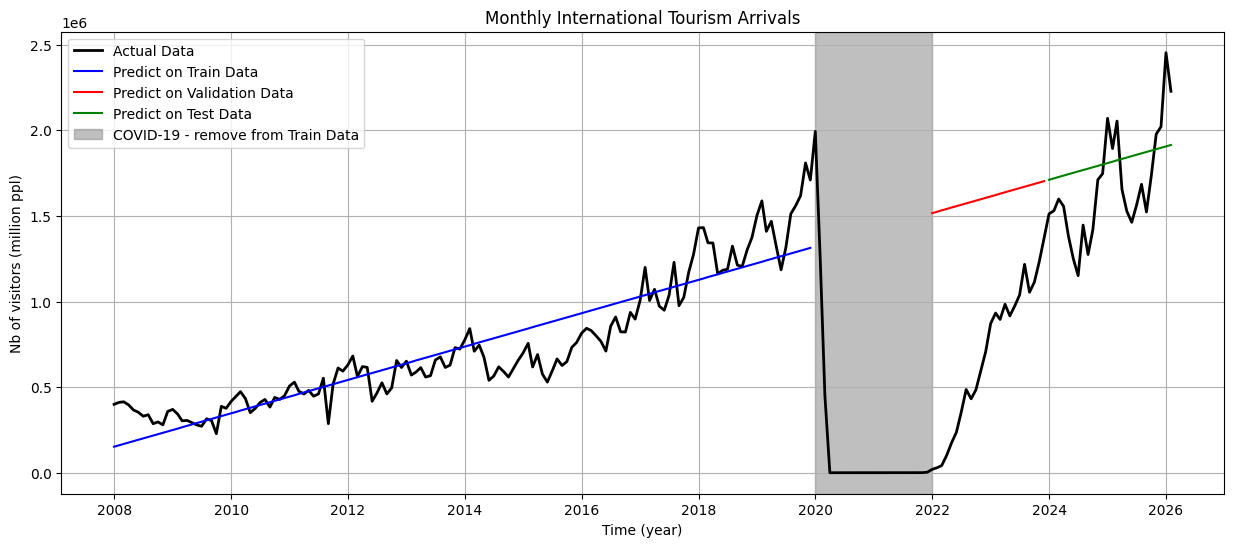

In [15]:
df_endo['date_month_start'] = pd.to_datetime(df_endo['date_month_start'])
plt.figure(figsize=(15, 6))

#actual data
plt.plot(
    df_endo['date_month_start'],
    df_endo['international_arrivals_total'],
    color = 'black',
    linewidth = 2,
    label = 'Actual Data'
)

#Convert Y_train, Y_val, Y_test from scaled values into original data
def inverse_y(y_scaled):
    return y_scaled * y_std + y_mean

#now convert:
Y_train_true = inverse_y(Y_train)
Y_val_true = inverse_y(Y_val)
Y_test_true = inverse_y(Y_test)

Y_train_pred_endo_true = inverse_y(Y_train_pred_endo)
Y_val_pred_endo_true = inverse_y(Y_val_pred_endo)
Y_test_pred_endo_true = inverse_y(Y_test_pred_endo)

#train data, validation data, test data
plt.plot(df_train['date_month_start'], Y_train_pred_endo_true, color = 'blue', label = 'Predict on Train Data')
plt.plot(df_val['date_month_start'], Y_val_pred_endo_true, color = 'red', label = 'Predict on Validation Data')
plt.plot(df_test['date_month_start'], Y_test_pred_endo_true, color = 'green', label = 'Predict on Test Data')

#color the 2020 - 2022 period (COVID 19) - skip this data
plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), color = 'gray', alpha = 0.5, label = 'COVID-19 - remove from Train Data')

plt.title("Monthly International Tourism Arrivals")
plt.xlabel("Time (year)")
plt.ylabel("Nb of visitors (million ppl)")
plt.legend(loc = 'upper left')
plt.grid(True)
plt.show()

From the graph: the predicted lines are smoother than acutal data 
=> Linear Regression Model learns the general trend but cannot reflect sudden changes and strong seasonal patterns, which means that it is too simple to capture seasonal fluctuations and post-COVID recovery dynamics

**Need to try using more variables, and now solve in Normal Equation to see the different**

### **d. Using Normal Equation, with more variables**

In [16]:
def normal_equation(X, Y):
    #theta = (X^TX)^-1 X^T Y
    XTX = np.dot(X.T, X)
    XTX_inv = np.linalg.inv(XTX)
    XTY = np.dot(X.T, Y)
    theta = np.dot(XTX_inv, XTY)
    return theta

**Run Normal Equation**

In [17]:
print("\n---Normal Equation---")
theta_comb = normal_equation(X_train_comb, Y_train)
print("Normalized Theta:", theta_comb.flatten())


---Normal Equation---
Normalized Theta: [ 4.58907558e-17  9.16575521e-01  6.32679585e-02 -4.03924329e-02]


**Normal Equation Evaluation**

In [18]:
Y_train_pred_comb = predict_Y(theta_comb, X_train_comb)
Y_val_pred_comb = predict_Y(theta_comb, X_val_comb)
Y_test_pred_comb = predict_Y(theta_comb, X_test_comb)

print("\nEvaluate Normal Equation on TRAIN set:")
evaluate_model(Y_train, Y_train_pred_comb)
print("\nEvaluate Normal Equation on VALIDATION set:")
evaluate_model(Y_val, Y_val_pred_comb)
print("\nEvaluate Normal Equation on TEST set:")
evaluate_model(Y_test, Y_test_pred_comb)


Evaluate Normal Equation on TRAIN set:
MAE: 0.3078 | MSE: 0.1595 | RMSE: 0.3994 | R^2: 0.8394

Evaluate Normal Equation on VALIDATION set:
MAE: 2.5601 | MSE: 7.5592 | RMSE: 2.7494 | R^2: -4.9295

Evaluate Normal Equation on TEST set:
MAE: 0.7182 | MSE: 0.6890 | RMSE: 0.8301 | R^2: -0.0001


**Actual - Predict Visualization in Train, Validation, Test Set - NORMAL EQUATION**

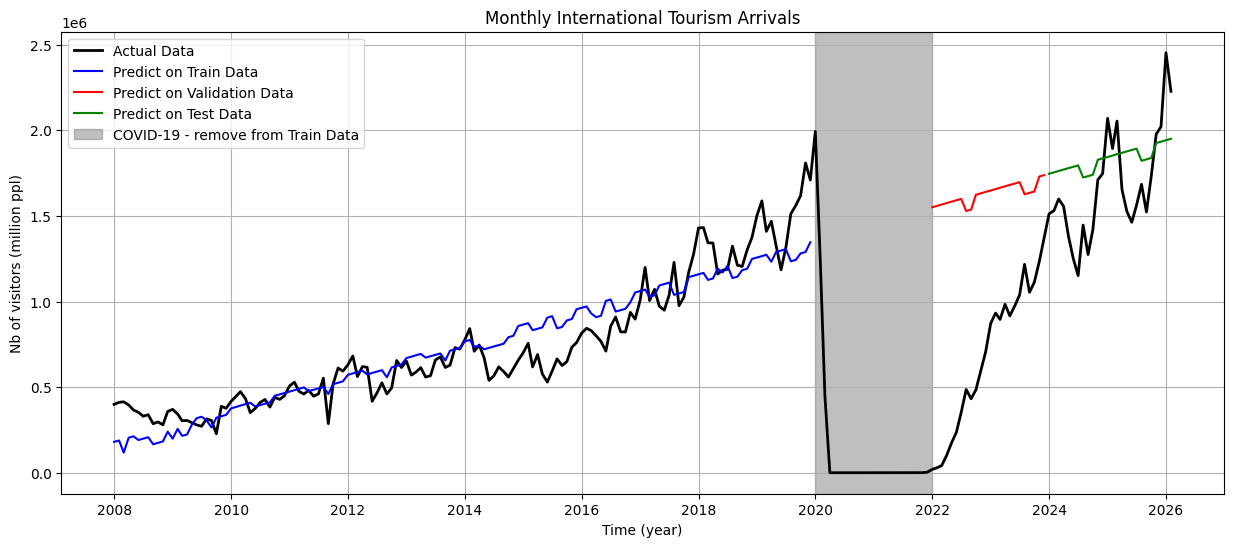

In [19]:
df_comb['date_month_start'] = pd.to_datetime(df_comb['date_month_start'])
plt.figure(figsize=(15, 6))

#actual data
plt.plot(
    df_comb['date_month_start'],
    df_comb['international_arrivals_total'],
    color = 'black',
    linewidth = 2,
    label = 'Actual Data'
)

#Convert Y_train, Y_val, Y_test from scaled values into original data
Y_train_pred_comb_true = inverse_y(Y_train_pred_comb)
Y_val_pred_comb_true = inverse_y(Y_val_pred_comb)
Y_test_pred_comb_true = inverse_y(Y_test_pred_comb)

#train data, validation data, test data
plt.plot(df_train['date_month_start'], Y_train_pred_comb_true, color = 'blue', label = 'Predict on Train Data')
plt.plot(df_val['date_month_start'], Y_val_pred_comb_true, color = 'red', label = 'Predict on Validation Data')
plt.plot(df_test['date_month_start'], Y_test_pred_comb_true, color = 'green', label = 'Predict on Test Data')

#color the 2020 - 2022 period (COVID 19) - skip this data
plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), color = 'gray', alpha = 0.5, label = 'COVID-19 - remove from Train Data')

plt.title("Monthly International Tourism Arrivals")
plt.xlabel("Time (year)")
plt.ylabel("Nb of visitors (million ppl)")
plt.legend(loc = 'upper left')
plt.grid(True)
plt.show()

The Normal Equation model also captures the overall upward trend in international arrivals, but its predictions remain smoother than the actual data. Although the additional event variables slightly adjust the forecast, the model still cannot fully reflect strong seasonal fluctuations and the abrupt post-COVID recovery. This suggests that the added binary event flags are not sufficient to model the complexity of the time series.

---

## **3. Model Comparison via Evaluation**

**Evaluation Metrics Comparison**
| Data | Evaluation | Gradient Descent | Normal Equation |
| :--- | :--- | :--- | :--- |
| **TRAIN** | MAE | 0.3133 | 0.3078 |
| | MSE | 0.1661 | 0.1595 |
| (2008-2019)| RMSE | 0.4076 | 0.3994 |
| | R² | 0.8327 | 0.8394 |
| **VALIDATION**| MAE | 2.5111 | 2.5601 |
| | MSE | 7.2674 | 7.5592|
| (2022-2023)| RMSE | 2.6958 | 2.7494 |
| | R² | -4.7006 | -4.9295 |
| **TEST** | MAE | 0.7235 | 0.7182 |
| | MSE | 0.6883 | 0.6890 |
| (2024-2026)| RMSE | 0.8296 | 0.8301 |
| | R² | 0.0010 | -0.0001 |

**Convert into Number of Visitors**

In [20]:
print("\n--- EVALUATION IN ORIGINAL UNITS (NB OF VISITORS) ---")
print("\n[VALIDATION SET]")
print("Gradient Descent Model:")
evaluate_model(Y_val_true, Y_val_pred_endo_true)
print("Normal Equation Model:")
evaluate_model(Y_val_true, Y_val_pred_comb_true)

print("\n[TEST SET]")
print("Gradient Descent Model:")
evaluate_model(Y_test_true, Y_test_pred_endo_true)
print("Normal Equation Model:")
evaluate_model(Y_test_true, Y_test_pred_comb_true)


--- EVALUATION IN ORIGINAL UNITS (NB OF VISITORS) ---

[VALIDATION SET]
Gradient Descent Model:
MAE: 932312.9332 | MSE: 1001809329683.6239 | RMSE: 1000904.2560 | R^2: -4.7005
Normal Equation Model:
MAE: 950532.9916 | MSE: 1042061289156.0809 | RMSE: 1020814.0326 | R^2: -4.9295

[TEST SET]
Gradient Descent Model:
MAE: 268616.5763 | MSE: 94878092318.7366 | RMSE: 308022.8763 | R^2: 0.0010
Normal Equation Model:
MAE: 266659.9041 | MSE: 94985880346.8868 | RMSE: 308197.7942 | R^2: -0.0001



| Set | Metric | Gradient Descent (Univariate) | Normal Equation (Multivariate) |
| :--- | :--- | :--- | :--- |
| **VALIDATION** | MAE | 932,328.56 | 950,532.99 |
| (2022-2023) | RMSE | 1,000,918.50 | 1,020,814.03 |
| | R² | -4.7006 | -4.9295 |
| **TEST** | MAE | 268,624.82 | 266,659.90 |
| (2024-2026) | RMSE | 308,031.16 | 308,197.79 |
| | R² | 0.0010 | -0.0001 |


**Comparison:** 

* MAE, MSE, RMSE: the smaller value, the better performance

* R^2: the higher value, the better explanatory power

* To understand the real-world impact, the MAE and RMSE are also interpreted in terms of actual visitor numbers

**1. Train Set:** Normal Equation fits the training data slightly better

**2. Validation Set:** Gradient Descent generalizes slightly better on validation set

* The validation period is highly unstable due to initial post-COVID recovery. Both models struggle heavily (negative R²), but GD's MAE is off by roughly **932,328 visitors/month**, which is slightly better than NE's error of 950,532

**3. Test Set:** Almost equal

* GD very slight better RMSE (308,031 vs 308,197) and R² (0.0010 vs -0.0001)

* NE very slight better MAE (266,659 vs 268,624). This means that on avg, the NE model' absolute monthly prediction is closer to the real number by a small margin of **1,965 visitors**

* difference is very small

=> Both models perform almost identically on test set

==> **Overall, the additional exogenous variables (`positive_event_flag` and `negative_event_flag`) contribute only limited predictive value in curent linear formulation**

**IN GENERAL**

Both models capture the long-term trend, but they do not model the post-COVID recovery period well. 

This is reflected in the poor validation performance and the negative R² values. 

The results suggest that the current linear features are still too simple to capture seasonal fluctuations and post-COVID recovery dynamics.

POV: actual error margin on Test Set (MAE of over **266,000 visitors/month**) need to upgrade to more complex, non-linear ML in future stages